# Finding the Ground State Energy of a Molecule: the Code

This kata introduces you to the problem of finding the ground state energy of a molecule.

This kata consists of two parts:
1. [Part I](./GroundStateEnergyTheory.ipynb) walks you through the theory behind the approach we'll be taking, illustrated with a few Python demos.
2. Part II (this notebook) offers a series of Workbench problems and demos focused on implementing the described approach as a quantum program.

In [ ]:
# Execute this cell to prepare the test infrastructure
from psiqdk.workbench import Qubits
from test_GroundStateEnergy import problem, HamiltonianTerm

## Problem 1. Single-qubit Pauli product rotation

A single-qubit Pauli product rotation (PPR) can be written as $\exp(i \theta P)$, where $P$ is one of the Pauli matrices $X$, $Y$, or $Z$.

**Inputs:** 

1. A Qubits register of length $1$ in an arbitrary superposition state.
2. A rotation angle $\theta$, in radians, represented as `float`.
3. Boolean values `is_x` and `is_z` specifying the matrix $P$ as follows:
   - `is_x = True` and `is_z = False` - $X$
   - `is_x = True` and `is_z = True` - $Y$
   - `is_x = False` and `is_z = True` - $Z$

   You are guaranteed that at least one of the values is `True`, that is, the matrix $P$ will never be the identity matrix.

**Goal:** 
Implement the single-qubit PPR on the given Qubits register.

<details>
  <summary><b>Need a hint?</b></summary>
  
Remember that the rotation gates $R_x$, $R_y$, and $R_z$ are expressed as exponents of Pauli matrices too.
</details>

In [ ]:
@problem
def single_qubit_ppr(reg: Qubits, theta: float, is_x: bool, is_z: bool) -> None:
    # Write your code here
    ...

## Problem 2. Two-qubit Pauli product rotation

A two-qubit Pauli product rotation (PPR) can be written as $\exp(i \theta P_0 \otimes P_1)$, where each $P_j$ is one of the Pauli matrices $X$, $Y$, or $Z$.

**Inputs:** 

1. A Qubits register of length $2$ in an arbitrary superposition state.
2. A rotation angle $\theta$, in radians, represented as `float`.
3. Bit masks `x_mask` and `z_mask` specifying the matrices $P_0$ and $P_1$ as follows:
   - Each bit position in the two bit masks corresponds to one qubit: the least significant bit corresponds to qubit 0 (matrix $P_0$), and the second (the most significant bit) - to qubit 1 (matrix $P_1$).
   - The bits of `x_mask` and `z_mask` in that position act the same as the Boolean values `is_x` and `is_z` from the previous problem: they specify whether $P_j$ is $X$, $Y$, $Z$, or $I$.
   - Note that this time one of the Pauli matrices $P_j$ (but not both!) can be the identity $I$.

   For example, `x_mask = 2 = 0b10` and `z_mask = 1 = 0b01` describe two matrices: 
   
   - For bit 0, `is_x = False` and `is_z = True` (the least significant bit of the masks), so $P_0 = Z$.
   - For bit 1, `is_x = True` and `is_z = False` (the most significant bit of the masks), so $P_0 = X$.

**Goal:** 
Implement the two-qubit PPR on the given Qubits register.

In [ ]:
@problem
def two_qubit_ppr(reg: Qubits, theta: float, x_mask: bool, z_mask: bool) -> None:
    # Write your code here
    ...

## Problem 3. Implement one Trotter step (first-order Trotter decomposition)

**Inputs:** 

1. A Qubits register of length $2$ in an arbitrary superposition state.
2. The evolution time $t$. (Assume that this parameter is already scaled by the number of Trotter steps $N$.)
3. The two-qubit Hamiltonian, represented as a linear combination of $m$ tensor products of pairs of Pauli matrices:
   $$H = \sum_{j = 0}^{m-1} c_j P_0^{(j)} \otimes P_1^{(j)}$$
   The Hamiltonian is given as a list of $m$ objects of `HamiltonianTerm` class in the following format:
   - The field `c` is the coefficient $c_j$.
   - The fields `x_mask` and `z_mask` are masks that describe the Pauli matrices $P_0^{(j)}$ and $P_1^{(j)}$ in the same format as problem 2.

**Goal:** Implement one Trotter step in the first-order Trotter decomposition. In other words, apply the following unitaries in the following order:

$$e^{-i t c_0 P_0^{(0)} \otimes P_1^{(j)}}, e^{-i t c_1 P_0^{(1)} \otimes P_1^{(1)}}, ..., e^{-i t c_{m-1} P_0^{(m-1)} \otimes P_1^{(m-1)}}$$

> Note that changing the order of unitaries within the Trotter step changes the resulting unitary - remember that the individual unitaries in this expression don't commute!
> Any order of unitaries yields a valid approximation that becomes increasingly more accurate as the number of Trotter steps increases. 
>
> However, this problem asks you to implement a specific unitary and will test your solution based on this requirement, so the order in which you apply the terms matters!

In [ ]:
@problem
def trotter_step(reg: Qubits, t: float, terms: list[HamiltonianTerm]) -> None:
    # Write your code here
    ...

## Problem 4. Implement first-order Trotter decomposition

**Inputs:** 

1. A Qubits register of length $2$ in an arbitrary superposition state.
2. The total evolution time $t$.
3. The two-qubit Hamiltonian, represented as a linear combination of $m$ tensor products of pairs of Pauli matrices in the same format as in the previous problem.
4. The number of Trotter steps $n$.

**Goal:** Implement first-order Trotter decomposition with $n$ steps, with each step following the definition from the previous problem.

In [ ]:
@problem
def trotter_approximation(reg: Qubits, t: float, terms: list[HamiltonianTerm], n: int) -> None:
    # Write your code here
    ...

## Demo: Finding the ground state energy for $H_2$ molecule

Finally, let's put all the pieces together! The following demo shows how to use first-order Trotter decomposition as an input to quantum phase estimation to solve a realistic problem: finding the ground state energy of the $H_2$ molecule as a function of bond length - the distance between the two hydrogen nuclei. By iterating over different values of bond lengths and calculating the ground state energy for each one you can estimate the actual bond length in a molecule - it will be the value with the lowest energy. 

Note that we're using the hardcoded parameters of the qubits Hamiltonian given in the paper ["Scalable Quantum Simulation of Molecular Energies" by O’Malley et al](https://arxiv.org/pdf/1512.06860), table 1. The Hamiltonian has the following form:

$$H = g_0 I_0 \otimes I_1 + g_1 Z_0 \otimes I_1 + g_2 I_0 \otimes Z_1 + g_3 Z_0 \otimes Z_1 + g_4 X_0 \otimes X_1 + g_5 Y_0 \otimes Y_1$$

We're using a fixed state $\ket{10}$ as an approximation of the eigenstate that encodes the ground state of $H_2$; it turns out that it is close enough to the true state to serve our goals!

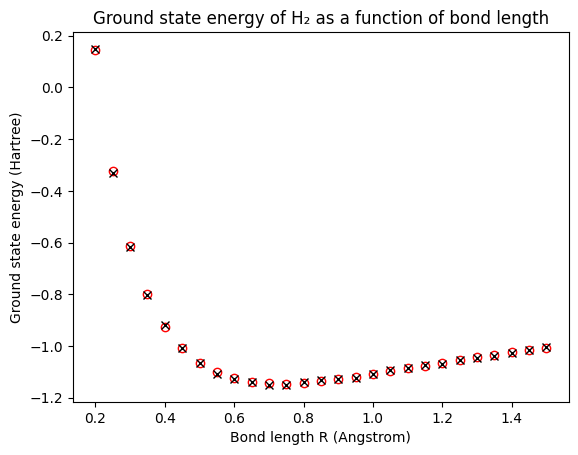

In [1]:
import numpy as np
from psiqdk.workbench import QPU, QUFixed, Qubits, Qubrick, units
from psiqdk.algorithms import QPE
from test_GroundStateEnergy import HamiltonianTerm, masks_as_pauli

class TrotterUnitary(Qubrick):
    '''Approximation of unitary time evolution operator for the given Hamiltonian using first-order Trotter decomposition.'''

    def __init__(self, terms: list[HamiltonianTerm], **kwargs):
        '''Construct the Qubrick.

        Args:
            terms (list[HamiltonianTerm]): The Hamiltonian expressed as a list of terms.'''
        super().__init__(**kwargs)
        self.terms = terms

    def _compute(
        self,
        reg: Qubits,
        n_steps: int,
        evolution_time: float,
        ctrl: Qubits | None = None
    ):
        '''Execute the circuit.

        Args:
            reg (Qubits): The register the operator is acting on.
            n_steps (int): Number of Trotter steps.
            evolution_time (float): Total evolution time.
            ctrl (Qubits, None): Qubit register to control the unitary on. Defaults to None.
        '''
        for _ in range(n_steps):
            for term in self.terms:
                reg.ppr(evolution_time / n_steps * term.c * units.rad, term.x_mask, term.z_mask, cond=ctrl)


def hamiltonian_from_terms(terms: list[HamiltonianTerm]) -> list[list[complex]]:
    '''Convert a list of two-qubit Hamiltonian terms to the Hamiltonian (exact).'''
    ham = np.zeros((4, 4), dtype=complex)
    for term in terms:
        p0 = masks_as_pauli(term.x_mask, term.z_mask, 0)
        p1 = masks_as_pauli(term.x_mask, term.z_mask, 1)
        tensor = np.kron(p1.matrix, p0.matrix)
        ham += term.c * tensor
    return ham


# Hamiltonian coefficients format: bond length: [I, Z0, Z1, Z0Z1, X0X1, Y0Y1]
# Data from "Scalable Quantum Simulation of Molecular Energies" by O’Malley et al, https://arxiv.org/pdf/1512.06860, table 1.
h2_hamiltonian_coefficients = {
    0.20: [2.8489, 0.5678, -1.4508, 0.6799, 0.0791, 0.0791],
    0.25: [2.1868, 0.5449, -1.2870, 0.6719, 0.0798, 0.0798],
    0.30: [1.7252, 0.5215, -1.1458, 0.6631, 0.0806, 0.0806],
    0.35: [1.3827, 0.4982, -1.0226, 0.6537, 0.0815, 0.0815],
    0.40: [1.1182, 0.4754, -0.9145, 0.6438, 0.0825, 0.0825],
    0.45: [0.9083, 0.4534, -0.8194, 0.6336, 0.0835, 0.0835],
    0.50: [0.7381, 0.4325, -0.7355, 0.6233, 0.0846, 0.0846],
    0.55: [0.5979, 0.4125, -0.6612, 0.6129, 0.0858, 0.0858],
    0.60: [0.4808, 0.3937, -0.5950, 0.6025, 0.0870, 0.0870],
    0.65: [0.3819, 0.3760, -0.5358, 0.5921, 0.0883, 0.0883],
    0.70: [0.2976, 0.3593, -0.4826, 0.5818, 0.0896, 0.0896],
    0.75: [0.2252, 0.3435, -0.4347, 0.5716, 0.0910, 0.0910],
    0.80: [0.1626, 0.3288, -0.3915, 0.5616, 0.0925, 0.0925],
    0.85: [0.1083, 0.3149, -0.3523, 0.5518, 0.0939, 0.0939],
    0.90: [0.0609, 0.3018, -0.3168, 0.5421, 0.0954, 0.0954],
    0.95: [0.0193, 0.2895, -0.2845, 0.5327, 0.0970, 0.0970],
    1.00: [-0.0172, 0.2779, -0.2550, 0.5235, 0.0986, 0.0986],
    1.05: [-0.0493, 0.2669, -0.2282, 0.5146, 0.1002, 0.1002],
    1.10: [-0.0778, 0.2565, -0.2036, 0.5059, 0.1018, 0.1018],
    1.15: [-0.1029, 0.2467, -0.1810, 0.4974, 0.1034, 0.1034],
    1.20: [-0.1253, 0.2374, -0.1603, 0.4892, 0.1050, 0.1050],
    1.25: [-0.1452, 0.2286, -0.1413, 0.4812, 0.1067, 0.1067],
    1.30: [-0.1629, 0.2203, -0.1238, 0.4735, 0.1083, 0.1083],
    1.35: [-0.1786, 0.2123, -0.1077, 0.4660, 0.1100, 0.1100],
    1.40: [-0.1927, 0.2048, -0.0929, 0.4588, 0.1116, 0.1116],
    1.45: [-0.2053, 0.1976, -0.0792, 0.4518, 0.1133, 0.1133],
    1.50: [-0.2165, 0.1908, -0.0666, 0.4451, 0.1149, 0.1149]
}

bits_of_precision = 8
n_steps = 11
evolution_time = 2

qpu = QPU()

# print("| Bond length | Result | Expected |")
bond_lengths = []
qpe_results = []
expected_energies = []
for bond_length, coef in h2_hamiltonian_coefficients.items():
    # Construct Hamiltonian terms from coefficients (hardcode specific Paulis)
    terms = [
        HamiltonianTerm(coef[0], 0, 0),
        HamiltonianTerm(coef[1], 0, 1),
        HamiltonianTerm(coef[2], 0, 2),
        HamiltonianTerm(coef[3], 0, 3),
        HamiltonianTerm(coef[4], 3, 0),
        HamiltonianTerm(coef[5], 3, 3)
    ]

    # Initialize registers
    qpu.reset(bits_of_precision + 2)
    eigenstate = Qubits(2, "eigenstate", qpu)
    phase_reg = QUFixed(bits_of_precision, bits_of_precision, "phase", qpu)

    # Calculate eigenvalue of the Hamiltonian classically for comparison
    hamiltonian = hamiltonian_from_terms(terms)
    eig_values, _ = np.linalg.eigh(hamiltonian)
    expected_energy = eig_values[0]

    # Prepare eigenstate corresponding to the ground state (the first element of return)
    eigenstate[0].x()

    # Create Trotter and QPE Qubricks
    trotter_unitary = TrotterUnitary(terms)
    qpe = QPE(bits_of_precision, unitary=trotter_unitary)
    qpe.compute(eigenstate, phase_reg, n_steps=n_steps, evolution_time=evolution_time)

    # Find the most probable measurement outcome instead of running the QPE circuit repeatedly
    def get_most_probable_phase(phase_qubits: QUFixed):
        """Get the most probable phase from a qubit register."""
        most_probable_phase_index = np.argmax(
            [phase_qubits.peek_read_probability(i) for i in range(1 << phase_qubits.radix)]
        )
        return most_probable_phase_index / (1 << phase_qubits.radix)

    meas_res = get_most_probable_phase(phase_reg)

    # Add coef[0] to compensate for the bug - controlled PPRs with zero masks have no effect on the state
    result = - meas_res * 2 * np.pi / evolution_time + coef[0]

    # print(f"|    {bond_length:.2f}     | {result:.03f} | {expected_energy:.03f} |")
    bond_lengths.append(bond_length)
    qpe_results.append(result)
    expected_energies.append(expected_energy)

import matplotlib.pyplot as plt
plt.figure()
plt.plot(bond_lengths, expected_energies, 'o', mfc='none', mec='red')
plt.plot(bond_lengths, qpe_results, 'x', mec='black')
plt.title('Ground state energy of H₂ as a function of bond length')
plt.xlabel('Bond length R (Angstrom)')
plt.ylabel('Ground state energy (Hartree)')
plt.show()

## Part II conclusion

Congratulations! In this kata you learned the basics of using quantum computing for solving quantum chemistry problems.
Here are a few key concepts to keep in mind:

* Finding the ground state energy of a molecule is common building block in chemistry problems that can be solved using quantum computing.
* The evolution of a quantum-mechanical system, such as a molecule, over time is described by the Schrödinger equation. The time-independent variant of this equation describes states that don't change over time, that is, eigenstates of the system, and their energy values. This means that we can formulate the problem of finding ground state energy as the problem of finding an eigenvalue of a given eigenstate of the system.
* Hamiltonian is the operator that describes the total energy of the system as a function of forces acting between particles within it. It is Hermitian (self-adjoint) but not unitary. We transform it into a unitary time evolution operator which is unitary and thus can act as the input to the phase estimation problem.
* To simplify implementation of the unitary time evolution operator, we represent its Hamiltonian as a sum of simpler terms (tensor products of Pauli matrices) and then approximate the unitary time evolution operator as a series of these terms, applied in small increments.